# Cetacean MLP — Inference on ARBAS

Loads the full-corpus L4 model trained in notebook 6 and runs inference
on the ARBAS Perch embeddings.  
Output: one parquet + one CSV with all four prediction strategies
joined to the original metadata (wav_path, segment_index, offset_s).

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}")

device: cuda


In [2]:
# ── HARRAPATU paths ───────────────────────────────────────────────────────────
MODEL_PATH = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/full_corpus_model/model_l4_full_corpus.pt')
EMB_PATH   = Path('/data2/mromaniuc/cet-det/inference_harrapatu/data/embeddings.npy')
META_PATH  = Path('/data2/mromaniuc/cet-det/inference_harrapatu/data/metadata.csv')
OUT_DIR    = Path('/data2/mromaniuc/cet-det/inference_harrapatu/predictions')
OUT_DIR.mkdir(exist_ok=True, parents=True)

for p in [MODEL_PATH, EMB_PATH, META_PATH]:
    print(f"{'OK' if p.exists() else 'MISSING':7s}  {p}")

OK       /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/full_corpus_model/model_l4_full_corpus.pt
OK       /data2/mromaniuc/cet-det/inference_harrapatu/data/embeddings.npy
OK       /data2/mromaniuc/cet-det/inference_harrapatu/data/metadata.csv


## 1. MLP definition (must match training)

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(
                model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy()
            )
    return np.concatenate(out, axis=0)

## 2. Load model bundle

In [4]:
b = torch.load(MODEL_PATH, map_location='cpu')

class_names = b['class_names']
n_cls       = b['n_classes']
bg_idx      = b['bg_idx']
bg_label    = b['bg_label']
sp_labels   = [i for i, c in enumerate(class_names) if i != bg_idx]

model = MLP(b['in_dim'], n_cls, hidden=b['hidden'], dropout=b['dropout'])
model.load_state_dict(b['model_state'])
model.to(DEVICE)
model.eval()

sc_mean  = b['scaler_mean']
sc_scale = b['scaler_scale']

print(f"Model loaded — {n_cls} classes: {class_names}")
print(f"Trained on:   {b['datasets_trained']}")
print(f"Val macro-F1: {b['val_macro_f1']:.4f}")
print(f"Temperature:  {b['temperature']:.3f}")

Model loaded — 11 classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
Trained on:   ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_testtrain', 'MONISH', 'OLTREMARE', 'WATKINS']
Val macro-F1: 0.7301
Temperature:  1.316


## 3. Load embeddings + metadata

In [5]:
# Embeddings: shape (117650, 1, 1536) — squeeze the middle dim
X_raw = np.load(EMB_PATH, mmap_mode='r')
print(f"Raw embedding shape: {X_raw.shape}")

if X_raw.ndim == 3:
    X_raw = X_raw[:, 0, :]   # (N, 1, 1536) → (N, 1536)
    print(f"After squeeze:       {X_raw.shape}")

assert X_raw.shape[1] == b['in_dim'], \
    f"Embedding dim {X_raw.shape[1]} != model in_dim {b['in_dim']}"

meta = pd.read_csv(META_PATH)
print(f"Metadata: {len(meta):,} rows  |  columns: {list(meta.columns)}")
assert len(meta) == len(X_raw), \
    f"Row count mismatch: meta={len(meta)} embeddings={len(X_raw)}"

Raw embedding shape: (298760, 1, 1536)
After squeeze:       (298760, 1536)
Metadata: 298,760 rows  |  columns: ['wav_path', 'segment_index', 'offset_s', 'top_predicted_class', 'top_logit_score']


## 4. Scale + forward pass

In [6]:
print("Scaling embeddings ...")
X_s = (np.asarray(X_raw, dtype=np.float32) - sc_mean) / sc_scale

print("Running forward pass ...")
logits = get_logits(model, X_s)
print(f"Logits shape: {logits.shape}")

Scaling embeddings ...
Running forward pass ...
Logits shape: (298760, 11)


## 5. Four prediction strategies

In [7]:
# ── A: argmax ────────────────────────────────────────────────────────────────
proba_raw = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_argmax  = proba_raw.argmax(axis=1)

# ── B: temperature ───────────────────────────────────────────────────────────
T         = b['temperature']
proba_temp = torch.softmax(torch.tensor(logits) / T, dim=1).numpy()
y_temp     = proba_temp.argmax(axis=1)

# ── C: vector scaling ────────────────────────────────────────────────────────
w_vec      = torch.tensor(b['vec_w'])
b_vec      = torch.tensor(b['vec_b'])
proba_vec  = F.softmax(torch.tensor(logits) * w_vec + b_vec, dim=1).numpy()
y_vec      = proba_vec.argmax(axis=1)

# ── D: PR threshold ──────────────────────────────────────────────────────────
pr_thresholds = b['pr_thresholds']
qualify       = np.zeros(proba_raw.shape, dtype=bool)
for ci, cn in enumerate(class_names):
    if ci == bg_idx:
        qualify[:, ci] = True
    else:
        qualify[:, ci] = proba_raw[:, ci] >= pr_thresholds.get(cn, 0.5)
y_pr = np.where(qualify, proba_raw, -np.inf).argmax(axis=1)

print("Predictions computed.")
for name, y in [('argmax', y_argmax), ('temp', y_temp),
                ('vec', y_vec), ('pr', y_pr)]:
    sp_pred = (y != bg_idx).sum()
    print(f"  {name:8s}  species detections: {sp_pred:,} / {len(y):,} "
          f"({sp_pred/len(y)*100:.2f}%)")

Predictions computed.
  argmax    species detections: 123,001 / 298,760 (41.17%)
  temp      species detections: 123,001 / 298,760 (41.17%)
  vec       species detections: 153,073 / 298,760 (51.24%)
  pr        species detections: 89,968 / 298,760 (30.11%)


## 6. Assemble output dataframe

In [8]:
out = meta.copy()

# Predicted labels
out['pred_argmax'] = [class_names[i] for i in y_argmax]
out['pred_temp']   = [class_names[i] for i in y_temp]
out['pred_vec']    = [class_names[i] for i in y_vec]
out['pred_pr']     = [class_names[i] for i in y_pr]

# Raw probability for each class
for ci, cn in enumerate(class_names):
    out[f'prob_{cn}'] = proba_raw[:, ci]

# Convenience: max species probability (excluding background)
sp_proba = proba_raw[:, sp_labels]
out['max_species_prob']   = sp_proba.max(axis=1)
out['max_species_class']  = [class_names[sp_labels[i]]
                              for i in sp_proba.argmax(axis=1)]

# Parse recorder / deployment from wav_path
out['wav_name'] = out['wav_path'].apply(lambda p: Path(p).name)

print(f"Output dataframe: {len(out):,} rows × {len(out.columns)} columns")
print(out[['wav_name','offset_s','pred_argmax','pred_pr','max_species_prob']].head(10).to_string(index=False))

Output dataframe: 298,760 rows × 23 columns
             wav_name  offset_s pred_argmax    pred_pr  max_species_prob
6338.251010055958.wav       0.0  background background          0.001855
6338.251010055958.wav       5.0  background background          0.006404
6338.251010055958.wav      10.0  background background          0.012250
6338.251010055958.wav      15.0  background background          0.002943
6338.251010055958.wav      20.0  background background          0.004286
6338.251010055958.wav      25.0  background background          0.003398
6338.251010055958.wav      30.0  background background          0.006774
6338.251010055958.wav      35.0  background background          0.004360
6338.251010055958.wav      40.0  background background          0.010661
6338.251010055958.wav      45.0  background background          0.007110


## 7. Save outputs

In [9]:
parquet_path = OUT_DIR / 'arbas_predictions_l4.parquet'
csv_path     = OUT_DIR / 'arbas_predictions_l4.csv'

out.to_parquet(parquet_path, index=False)
out.to_csv(csv_path, index=False)

print(f"Saved parquet → {parquet_path}")
print(f"Saved CSV     → {csv_path}")

Saved parquet → /data2/mromaniuc/cet-det/inference_harrapatu/predictions/arbas_predictions_l4.parquet
Saved CSV     → /data2/mromaniuc/cet-det/inference_harrapatu/predictions/arbas_predictions_l4.csv


## 8. Quick summary — detections per strategy

Detection counts per species per strategy:

strategy                    pred_argmax  pred_pr  pred_temp  pred_vec
species                                                              
Balaenoptera_acutorostrata           13        0         13        88
Balaenoptera_physalus                46        0         46       274
Delphinidae_unknown              103287    89209     103287    126287
Delphinus_delphis                   731       12        731        79
Globicephala_melas                    8        0          8        11
Grampus_griseus                      90       23         90       141
Orcinus_orca                       4205      252       4205      9329
Physeter_macrocephalus             1686        0       1686      4191
Stenella_coeruleoalba                98        2         98      4587
Tursiops_truncatus                12837      470      12837      8086


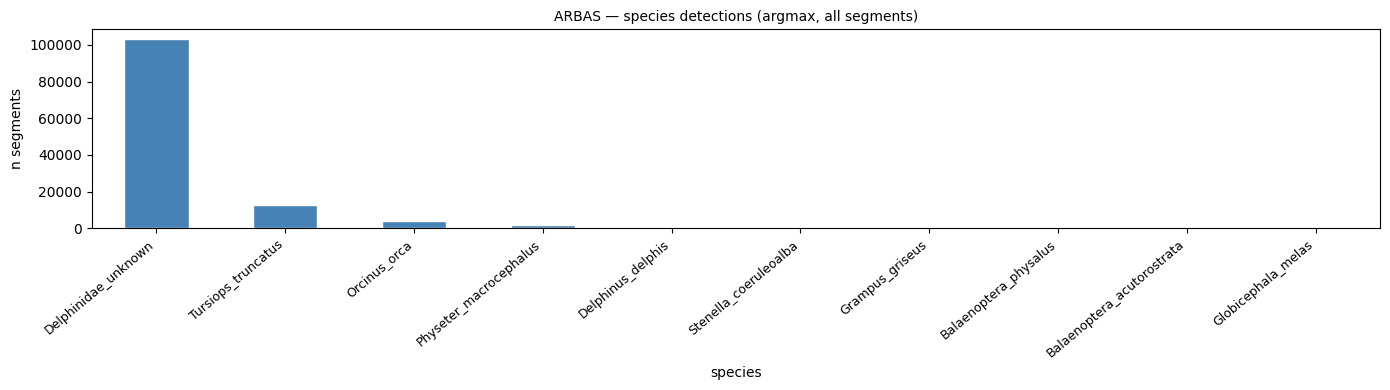

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

strategies = ['pred_argmax', 'pred_temp', 'pred_vec', 'pred_pr']

print("Detection counts per species per strategy:\n")
rows = []
for strat in strategies:
    sp_det = out[out[strat] != bg_label][strat].value_counts()
    for sp, n in sp_det.items():
        rows.append({'strategy': strat, 'species': sp, 'n_detections': n})
det_df = pd.DataFrame(rows)
pivot  = det_df.pivot(index='species', columns='strategy', values='n_detections').fillna(0).astype(int)
print(pivot.to_string())

# Bar chart — argmax detections by species
sp_counts = out[out['pred_argmax'] != bg_label]['pred_argmax'].value_counts()
if len(sp_counts) > 0:
    fig, ax = plt.subplots(figsize=(max(6, len(sp_counts)*1.2+2), 4))
    sp_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('ARBAS — species detections (argmax, all segments)', fontsize=10)
    ax.set_xlabel('species'); ax.set_ylabel('n segments')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'arbas_detections_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No species detections under argmax strategy.")

## 9. Detection timeline per recorder

One row per wav file, showing which segments triggered a species detection.

In [11]:
# Use argmax as the working strategy — swap to 'pred_pr' for conservative view
STRATEGY = 'pred_argmax'

detections = out[out[STRATEGY] != bg_label].copy()

if len(detections) == 0:
    print("No species detections found.")
else:
    print(f"{len(detections):,} species detections across "
          f"{detections['wav_name'].nunique():,} files\n")

    # Per-file detection summary
    summary = (
        detections
        .groupby(['wav_name', STRATEGY])
        .agg(n_segments=('offset_s', 'count'),
             first_offset_s=('offset_s', 'min'),
             last_offset_s=('offset_s', 'max'),
             mean_prob=('max_species_prob', 'mean'))
        .reset_index()
        .rename(columns={STRATEGY: 'species'})
        .sort_values(['wav_name', 'first_offset_s'])
    )
    print(summary.to_string(index=False))
    summary.to_csv(OUT_DIR / 'arbas_detection_summary.csv', index=False)
    print(f"\nSummary saved → {OUT_DIR}/arbas_detection_summary.csv")

123,001 species detections across 4,882 files

             wav_name                    species  n_segments  first_offset_s  last_offset_s  mean_prob
6338.251010060458.wav            Grampus_griseus           2           185.0          215.0   0.789915
6338.251010060958.wav               Orcinus_orca           3           145.0          170.0   0.567815
6338.251010061958.wav               Orcinus_orca          12            35.0          230.0   0.597246
6338.251010062458.wav               Orcinus_orca           6            15.0          195.0   0.545457
6338.251010062958.wav               Orcinus_orca           8            10.0          230.0   0.604239
6338.251010062958.wav         Globicephala_melas           1            15.0           15.0   0.722350
6338.251010062958.wav            Grampus_griseus           5            40.0          135.0   0.706831
6338.251010063458.wav        Delphinidae_unknown           1           230.0          230.0   0.627506
6338.251010063958.wav     